In [1]:
import novae

In [44]:
adata = novae.load_dataset(
    "Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE_outs",
    annotations=True,
    embeddings="corpus360M[multi-species]-model170M",
)[0]

[INFO] (novae.data._load.hf) Found 1 h5ad file(s) matching the filters.


In [45]:
import anndata as ad
from huggingface_hub import hf_hub_download

local_path = hf_hub_download(
    repo_id="prism-oncology/sandbox",
    filename="cirm_tutorials/crc_public_ref_subsample.h5ad",
    repo_type="dataset",
)

adata_ref = ad.read_h5ad(local_path)

In [46]:
import scanpy as sc

In [47]:
from sklearn.neighbors import NearestNeighbors

In [48]:
nn = NearestNeighbors(n_neighbors=1, metric="euclidean", algorithm="auto")

In [49]:
nn.fit(adata_ref.obsm["X_scConcept"])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'eu...an'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [50]:
_, indices = nn.kneighbors(adata.obsm["X_scConcept"])

In [51]:
adata.obs["new_cell_type"] = adata_ref.obs["cell_type_level2"].iloc[indices[:, 0]].values

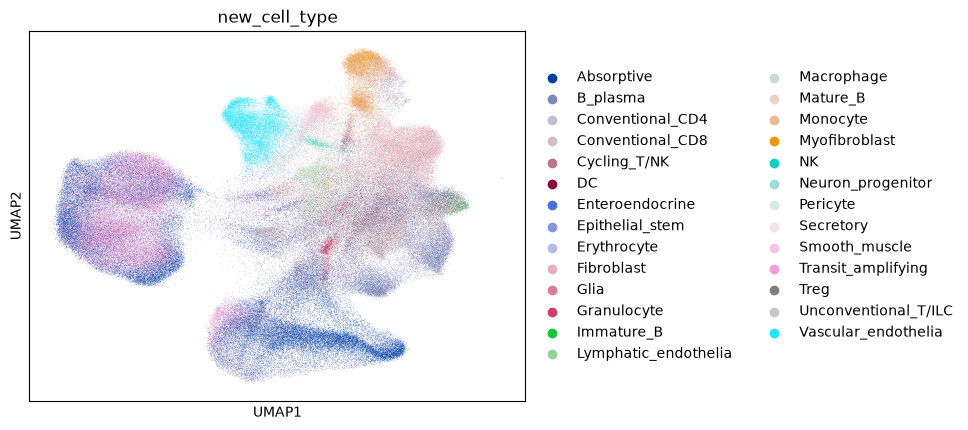

In [52]:
sc.pl.umap(adata, color="new_cell_type")

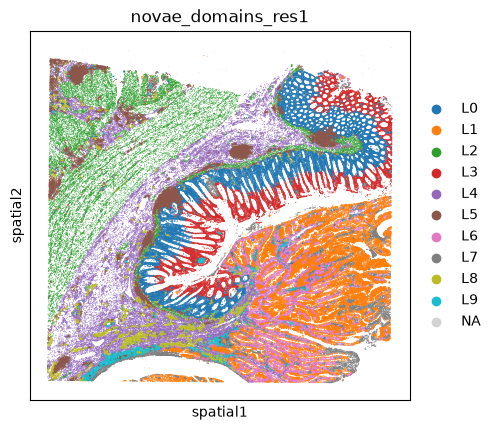

In [53]:
sc.pl.spatial(adata, color="novae_domains_res1", spot_size=15)

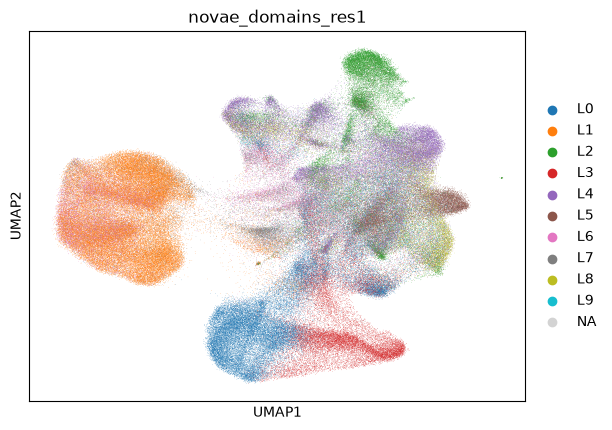

In [54]:
sc.pl.umap(adata, color="novae_domains_res1")